# Brain MRI Tumor Classifier — Training Notebook

**ResNet-50 transfer learning · 4-class brain tumour classification**

Dataset: [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) (Masoud Nickparvar, CC BY 4.0)  
Classes: `glioma` · `meningioma` · `notumor` · `pituitary`  
Runtime: **T4 GPU** (Runtime → Change runtime type → T4 GPU) — training takes ~25 min.

---

## Setup before running

**Colab Secrets** (click the 🔑 key icon in the left sidebar):

| Secret name | Value |
|---|---|
| `KAGGLE_USERNAME` | Your Kaggle username |
| `KAGGLE_KEY` | Your Kaggle API key (from kaggle.com/settings → API) |
| `HF_TOKEN` | HuggingFace **write** token (huggingface.co/settings/tokens) |
| `HF_USERNAME` | Your HuggingFace username |

Never hardcode credentials — Colab Secrets are encrypted and scoped to your account.

In [10]:
# ── Cell 0: GPU check ─────────────────────────────────────────────────────
import torch

print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device  : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected. Switch to T4 via Runtime → Change runtime type.")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.10.0+cu128
GPU     : True
Device  : Tesla T4


In [11]:
# ── Cell 1: Install dependencies & configure Kaggle ───────────────────────
!pip install -q kaggle huggingface_hub

import json, os
from google.colab import userdata

# Load credentials from Colab Secrets (never hardcode these)
kaggle_creds = {
    "username": userdata.get('KAGGLE_USERNAME'),
    "key":      userdata.get('KAGGLE_KEY'),
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print(f"Kaggle configured for user: {kaggle_creds['username']}")

Kaggle configured for user: rahuldas17723


In [12]:
# ── Cell 2: Download dataset ───────────────────────────────────────────────
import shutil

DATA_ROOT = '/data'

# Clean any leftover files from previous runs
if os.path.exists(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)
os.makedirs(DATA_ROOT)

# Download masoudnickparvar/brain-tumor-mri-dataset
# Structure after unzip: /data/Training/{glioma,meningioma,notumor,pituitary}/
#                        /data/Testing/{glioma,meningioma,notumor,pituitary}/
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p {DATA_ROOT} --unzip

# Verify folder structure (should show Training/ and Testing/ with 4 subfolders each)
print("\nDataset structure:")
for root, dirs, files in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 187MB/s]


Dataset structure:
data/  (0 files)
  Testing/  (0 files)
    meningioma/  (400 files)
    pituitary/  (400 files)
    glioma/  (400 files)
    notumor/  (400 files)
  Training/  (0 files)
    meningioma/  (1400 files)
    pituitary/  (1400 files)
    glioma/  (1400 files)
    notumor/  (1400 files)


In [13]:
# ── Cell 3: Dataset setup ──────────────────────────────────────────────────
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

TRAIN_DIR = '/data/Training'   # 4 class folders: glioma meningioma notumor pituitary
TEST_DIR  = '/data/Testing'
IMG_SIZE  = 224
BATCH_SIZE = 32

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(TRAIN_DIR, transform=train_tf)
test_ds  = ImageFolder(TEST_DIR,  transform=val_tf)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

# Sanity check — must be exactly these 4 classes
EXPECTED = ['glioma', 'meningioma', 'notumor', 'pituitary']
assert CLASS_NAMES == EXPECTED, (
    f"Unexpected classes: {CLASS_NAMES}. "
    f"Expected {EXPECTED}. Check that TRAIN_DIR points to /data/Training."
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Classes     : {CLASS_NAMES}")
print(f"Train images: {len(train_ds)}")
print(f"Test  images: {len(test_ds)}")
print("\nPer-class distribution (train):")
for cls, idx in train_ds.class_to_idx.items():
    count = sum(1 for _, label in train_ds.samples if label == idx)
    print(f"  {cls:20s}: {count}")

Classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']
Train images: 5600
Test  images: 1600

Per-class distribution (train):
  glioma              : 1400
  meningioma          : 1400
  notumor             : 1400
  pituitary           : 1400


In [14]:
# ── Cell 4: Model — ResNet-50 with fine-tuned head ────────────────────────
import torch.nn as nn
import torchvision.models as models

def build_model(num_classes: int) -> nn.Module:
    model = models.resnet50(weights='IMAGENET1K_V2')
    # Freeze all layers except layer4 and the new head
    for name, param in model.named_parameters():
        if 'layer4' not in name and 'fc' not in name:
            param.requires_grad = False
    in_features = model.fc.in_features   # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, num_classes),
    )
    return model

model = build_model(NUM_CLASSES).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print(f"Output classes   : {NUM_CLASSES}  → {CLASS_NAMES}")

Trainable params : 14,972,932 / 23,516,228  (63.7%)
Output classes   : 4  → ['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:
# ── Cell 5: Training ──────────────────────────────────────────────────────
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS     = 20
SAVE_PATH  = 'brain_mri_resnet50_v0.1.0.pt'

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-3,
)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Remove any stale checkpoint from a previous run
if os.path.exists(SAVE_PATH):
    os.remove(SAVE_PATH)
    print(f"Removed stale checkpoint: {SAVE_PATH}")


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (out.argmax(1) == labels).sum().item()
            n          += len(labels)
    return total_loss / n, correct / n


best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(test_loader,  train=False)
    scheduler.step()
    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), SAVE_PATH)
        flag = f'  ✓ best saved'
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
        f"test loss {va_loss:.4f} acc {va_acc:.3f}{flag}"
    )

print(f"\nBest test accuracy: {best_val_acc:.3f}")

Removed stale checkpoint: brain_mri_resnet50_v0.1.0.pt
Epoch 01/20 | train loss 0.4944 acc 0.830 | test loss 0.9737 acc 0.853  ✓ best saved
Epoch 02/20 | train loss 0.1928 acc 0.932 | test loss 0.3834 acc 0.897  ✓ best saved
Epoch 03/20 | train loss 0.1287 acc 0.954 | test loss 0.6991 acc 0.912  ✓ best saved
Epoch 04/20 | train loss 0.1061 acc 0.963 | test loss 0.4950 acc 0.936  ✓ best saved
Epoch 05/20 | train loss 0.0746 acc 0.974 | test loss 0.5528 acc 0.930
Epoch 06/20 | train loss 0.0670 acc 0.974 | test loss 0.5967 acc 0.937  ✓ best saved
Epoch 07/20 | train loss 0.0593 acc 0.982 | test loss 0.7801 acc 0.942  ✓ best saved
Epoch 08/20 | train loss 0.0446 acc 0.984 | test loss 0.8474 acc 0.943  ✓ best saved
Epoch 09/20 | train loss 0.0459 acc 0.985 | test loss 0.8375 acc 0.944  ✓ best saved
Epoch 10/20 | train loss 0.0352 acc 0.990 | test loss 0.8116 acc 0.941
Epoch 11/20 | train loss 0.0291 acc 0.991 | test loss 0.3481 acc 0.948  ✓ best saved
Epoch 12/20 | train loss 0.0367 acc 0.

              precision    recall  f1-score   support

      glioma      0.997     0.828     0.904       400
  meningioma      0.915     0.995     0.953       400
     notumor      0.910     0.983     0.945       400
   pituitary      0.998     1.000     0.999       400

    accuracy                          0.951      1600
   macro avg      0.955     0.951     0.950      1600
weighted avg      0.955     0.951     0.950      1600



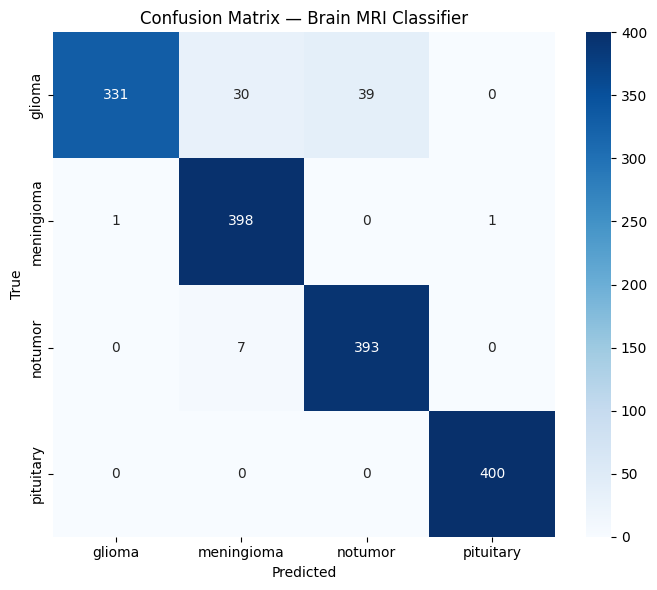

In [16]:
# ── Cell 6: Evaluation ────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        out = model(imgs.to(DEVICE))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Brain MRI Classifier')
plt.tight_layout()
plt.show()

In [17]:
# ── Cell 7: Push to HuggingFace Hub ───────────────────────────────────────
# Credentials are loaded from Colab Secrets — never hardcoded
from google.colab import userdata
from huggingface_hub import HfApi

HF_TOKEN    = userdata.get('HF_TOKEN')      # write token
HF_USERNAME = userdata.get('HF_USERNAME')   # your HF username
HF_REPO     = f"{HF_USERNAME}/brain-mri-resnet50"

assert HF_TOKEN,    "HF_TOKEN secret not set. Add it in the Colab Secrets sidebar."
assert HF_USERNAME, "HF_USERNAME secret not set. Add it in the Colab Secrets sidebar."
assert os.path.exists(SAVE_PATH), (
    f"{SAVE_PATH} not found. Make sure Cell 5 completed successfully."
)

api = HfApi()
api.create_repo(repo_id=HF_REPO, token=HF_TOKEN, exist_ok=True, private=False)

# Also upload a model card
model_card = f"""---
license: mit
tags:
  - medical-imaging
  - brain-tumor
  - resnet50
  - pytorch
---
# Brain MRI Tumor Classifier

ResNet-50 fine-tuned for 4-class brain tumour classification.

**Classes (alphabetical / ImageFolder order):** `glioma`, `meningioma`, `notumor`, `pituitary`

**Dataset:** [masoudnickparvar/brain-tumor-mri-dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

**Architecture:** ResNet-50 (IMAGENET1K_V2) + Dropout(0.4) + Linear(2048→4)

**Best test accuracy:** {best_val_acc:.3f}

**Disclaimer:** For educational/research use only. Not a clinical diagnostic tool.
"""
with open('README.md', 'w') as f:
    f.write(model_card)

api.upload_file(
    path_or_fileobj=SAVE_PATH,
    path_in_repo=SAVE_PATH,
    repo_id=HF_REPO,
    token=HF_TOKEN,
)
api.upload_file(
    path_or_fileobj='README.md',
    path_in_repo='README.md',
    repo_id=HF_REPO,
    token=HF_TOKEN,
)

print(f"Model pushed to : https://huggingface.co/{HF_REPO}")
print(f"Weights file    : {SAVE_PATH}")
print(f"Classes         : {CLASS_NAMES}")
print(f"Best test acc   : {best_val_acc:.3f}")
print()
print("Next steps:")
print("  1. Delete data/models/brain_mri_resnet50_v0.1.0.pt locally (if it exists)")
print("  2. Restart the backend — it will download the new weights automatically")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  brain_mri_resnet50_v0.1.0.pt:  30%|##9       | 28.3MB / 94.4MB            

Model pushed to : https://huggingface.co/rAhuL45647/brain-mri-resnet50
Weights file    : brain_mri_resnet50_v0.1.0.pt
Classes         : ['glioma', 'meningioma', 'notumor', 'pituitary']
Best test acc   : 0.951

Next steps:
  1. Delete data/models/brain_mri_resnet50_v0.1.0.pt locally (if it exists)
  2. Restart the backend — it will download the new weights automatically
